<a href="https://colab.research.google.com/github/Anuska111/Credit-Risk-Loan-Default-Pipeline-/blob/main/Credit_Risk_%26_Loan_Default_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/credit_risk_dataset.csv.zip")

In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.shape

(32581, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [10]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
loan_int_rate,9.563856
person_emp_length,2.747000
person_income,0.000000
person_age,0.000000
person_home_ownership,0.000000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_status,0.000000
loan_percent_income,0.000000


In [12]:
df.duplicated().sum()

np.int64(165)

In [13]:
#Target Variable Distribution
df["loan_status"].value_counts()

,count
loan_status,
0,25473
1,7108


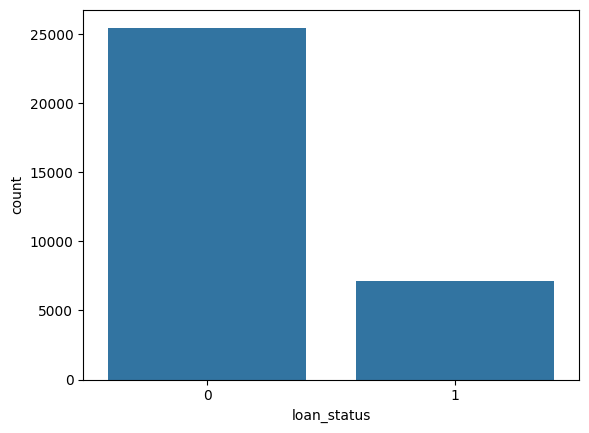

In [14]:
sns.countplot(x="loan_status", data=df)
plt.show()

In [15]:
# Feature Engineering
df["income_to_loan"] = df["person_income"] / df["loan_amnt"]

df["experience_per_age"] = (
    df["person_emp_length"] / df["person_age"]
)
df["interest_amount"] = (
    df["loan_amnt"] * df["loan_int_rate"] / 100
)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_to_loan,experience_per_age,interest_amount
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,1.685714,5.590909,5607.00
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.600000,0.238095,111.40
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,1.745455,0.040000,707.85
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,1.871429,0.173913,5330.50
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,1.554286,0.333333,4994.50


In [16]:
#Separate Features & Target
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [17]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
#Numerical Features
numerical_features = X_train.select_dtypes(
    include=["int64","float64"]
).columns

In [19]:
numerical_features

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'income_to_loan', 'experience_per_age', 'interest_amount'],
      dtype='object')

In [20]:
#Categorical Features
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

In [21]:
categorical_features

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [22]:
#Import Preprocessing Libraries
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [23]:
#Numerical Pipeline
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [24]:
#Categorical Pipeline
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [25]:
#Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numerical_features),
        ("cat", cat_pipeline, categorical_features)
    ]
)

In [26]:

from sklearn.ensemble import RandomForestClassifier

In [27]:
#Complete ML Pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

In [28]:
#Train Model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'income_to_loan', 'experience_per_age', 'interest_amount'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [29]:
#Predict on Test Data
y_pred = model.predict(X_test)

In [30]:
#Probability Prediction
y_prob = model.predict_proba(X_test)[:,1]

In [31]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

In [32]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[5066,   29],
       [ 403, 1019]])

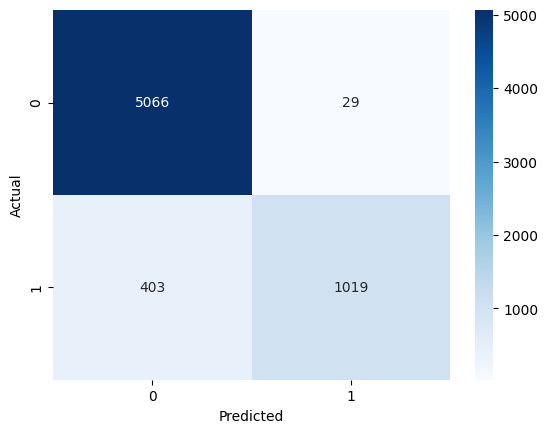

In [33]:
#Visualization
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



In [35]:
#Recall Score
from sklearn.metrics import recall_score
recall = recall_score(y_test,y_pred)

print(recall)

0.7165963431786216


In [36]:
#Precision Recall Curve
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

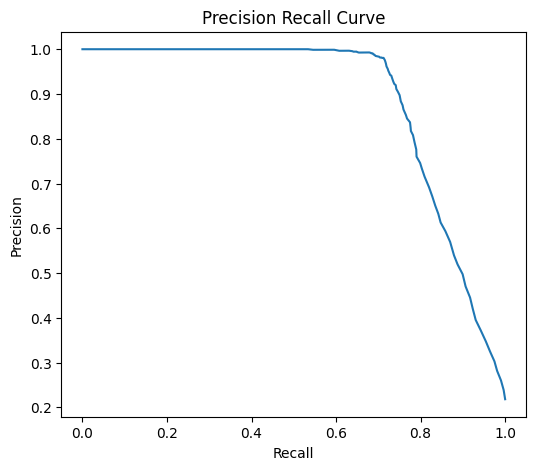

In [37]:
#Plot Precision Recall Curve
plt.figure(figsize=(6,5))
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

In [38]:
#Precision Recall AUC
from sklearn.metrics import auc
pr_auc = auc(recall,precision)

print(pr_auc)

0.8850324985013236


In [39]:
#GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,None],
    "classifier__min_samples_split":[2,5]
}

In [40]:
#Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [41]:
#Train GridSearchCV
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'income_to_loan', 'experie...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='recall')

In [42]:
print(grid.best_params_)

{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [43]:
print(grid.best_score_)

0.7200142823358112


In [44]:
#Best Model Prediction
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

In [45]:
#Feature Importance
feature_importance = best_model.named_steps["classifier"].feature_importances_

In [46]:
#Threshold Optimization
threshold = 0.35
y_pred_threshold = (y_prob >= threshold).astype(int)
print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5095
           1       0.87      0.76      0.81      1422

    accuracy                           0.92      6517
   macro avg       0.90      0.86      0.88      6517
weighted avg       0.92      0.92      0.92      6517



In [47]:
#Cross Validation
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)
print(cv_score)
print(cv_score.mean())

[0.72383465 0.73438874 0.7062445  0.71880492 0.71679859]
0.7200142823358112


In [48]:
#ROC AUC
from sklearn.metrics import roc_auc_score
roc = roc_auc_score(y_test, y_prob)
print(roc)

0.9298765094705518


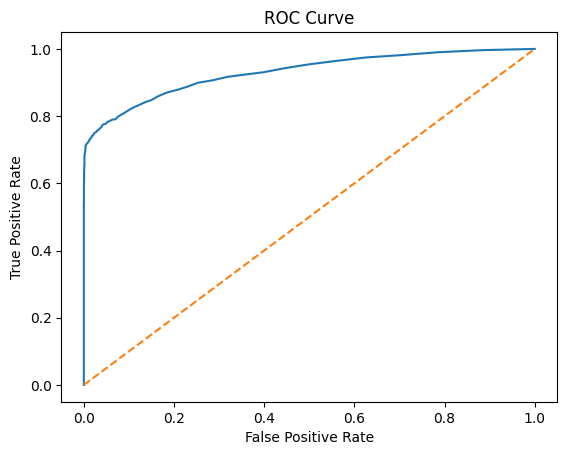

In [49]:
#ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [50]:
#Error Analysis
errors = X_test.copy()
errors["Actual"] = y_test.values
errors["Predicted"] = best_pred
errors[errors["Actual"] != errors["Predicted"]].head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_to_loan,experience_per_age,interest_amount,Actual,Predicted
7586,25,48000,MORTGAGE,8.0,PERSONAL,A,2250,8.49,0.05,N,3,21.333333,0.320000,191.025,1,0
31517,45,123000,RENT,2.0,EDUCATION,F,14000,NaN,0.11,N,17,8.785714,0.044444,NaN,1,0
20977,27,44004,RENT,0.0,PERSONAL,C,5000,13.79,0.11,N,8,8.800800,0.000000,689.500,1,0
18818,31,14400,RENT,0.0,EDUCATION,C,1250,NaN,0.09,N,8,11.520000,0.000000,NaN,1,0
9809,26,34320,RENT,2.0,EDUCATION,A,9000,6.62,0.26,N,2,3.813333,0.076923,595.800,1,0


In [51]:
#Predict Single Customer
new_customer = pd.DataFrame({
    "person_age":[28],
    "person_income":[60000],
    "person_home_ownership":["RENT"],
    "person_emp_length":[4],
    "loan_intent":["EDUCATION"],
    "loan_grade":["B"],
    "loan_amnt":[12000],
    "loan_int_rate":[10.5],
    "loan_percent_income":[0.20],
    "cb_person_default_on_file":["N"],
    "cb_person_cred_hist_length":[5]

})

# Apply the same feature engineering steps as performed on the training data
new_customer["income_to_loan"] = new_customer["person_income"] / new_customer["loan_amnt"]
new_customer["experience_per_age"] = (
    new_customer["person_emp_length"] / new_customer["person_age"]
)
new_customer["interest_amount"] = (
    new_customer["loan_amnt"] * new_customer["loan_int_rate"] / 100
)

best_model.predict(new_customer)
best_model.predict_proba(new_customer)

array([[0.99, 0.01]])

In [56]:
import joblib

joblib.dump(best_model, "credit_risk_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [58]:
joblib.dump(model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [65]:
# Install Streamlit if not already installed
!pip install streamlit -qq

import streamlit as st
import pandas as pd
import joblib

# Load trained pipeline
model = joblib.load("credit_risk_model.pkl")

st.set_page_config(
    page_title="Credit Risk & Loan Default Prediction",
    page_icon="🏦",
    layout="centered"
)

st.title("🏦 Credit Risk & Loan Default Prediction")
st.write("Enter applicant details to predict loan default risk.")

person_age = st.number_input("Age", 18, 100, 28)
person_income = st.number_input("Annual Income", min_value=1000, value=60000)
person_home_ownership = st.selectbox(
    "Home Ownership",
    ["RENT", "OWN", "MORTGAGE", "OTHER"]
)
person_emp_length = st.number_input(
    "Employment Length (Years)", min_value=0.0, value=4.0
)
loan_intent = st.selectbox(
    "Loan Purpose",
    ["EDUCATION", "MEDICAL", "PERSONAL", "VENTURE", "HOMEIMPROVEMENT", "DEBTCONSOLIDATION"]
)
loan_grade = st.selectbox(
    "Loan Grade",
    ["A", "B", "C", "D", "E", "F", "G"]
)
loan_amnt = st.number_input("Loan Amount", min_value=500, value=12000)
loan_int_rate = st.number_input(
    "Interest Rate (%)", min_value=0.0, value=10.5
)
loan_percent_income = st.number_input(
    "Loan Percent of Income", min_value=0.0, value=0.20
)
cb_person_default_on_file = st.selectbox(
    "Previous Default",
    ["N", "Y"]
)
cb_person_cred_hist_length = st.number_input(
    "Credit History Length", min_value=1, value=5
)

if st.button("Predict"):

    input_df = pd.DataFrame({
        "person_age":[person_age],
        "person_income":[person_income],
        "person_home_ownership":[person_home_ownership],
        "person_emp_length":[person_emp_length],
        "loan_intent":[loan_intent],
        "loan_grade":[loan_grade],
        "loan_amnt":[loan_amnt],
        "loan_int_rate":[loan_int_rate],
        "loan_percent_income":[loan_percent_income],
        "cb_person_default_on_file":[cb_person_default_on_file],
        "cb_person_cred_hist_length":[cb_person_cred_hist_length]
    })

    # Feature Engineering
    input_df["income_to_loan"] = (
        input_df["person_income"] / input_df["loan_amnt"]
    )
    input_df["experience_per_age"] = (
        input_df["person_emp_length"] / input_df["person_age"]
    )
    input_df["interest_amount"] = (
        input_df["loan_amnt"] * input_df["loan_int_rate"] / 100
    )

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        st.error(f"⚠️ High Risk of Loan Default\n\nProbability: {probability:.2%}")
    else:
        st.success(f"✅ Low Risk of Loan Default\n\nProbability: {probability:.2%}")

2026-07-29 17:55:40.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 17:55:40.628 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 17:55:40.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 17:55:40.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 17:55:40.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 17:55:40.641 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 17:55:40.644 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 17:55:40.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [66]:
import os

# Save the Streamlit app code to a file
streamlit_code = '''
# Install Streamlit if not already installed
!pip install streamlit -qq

import streamlit as st
import pandas as pd
import joblib

# Load trained pipeline
model = joblib.load("credit_risk_model.pkl")

st.set_page_config(
    page_title="Credit Risk & Loan Default Prediction",
    page_icon="🏦",
    layout="centered"
)

st.title("🏦 Credit Risk & Loan Default Prediction")
st.write("Enter applicant details to predict loan default risk.")

person_age = st.number_input("Age", 18, 100, 28)
person_income = st.number_input("Annual Income", min_value=1000, value=60000)
person_home_ownership = st.selectbox(
    "Home Ownership",
    ["RENT", "OWN", "MORTGAGE", "OTHER"]
)
person_emp_length = st.number_input(
    "Employment Length (Years)", min_value=0.0, value=4.0
)
loan_intent = st.selectbox(
    "Loan Purpose",
    ["EDUCATION", "MEDICAL", "PERSONAL", "VENTURE", "HOMEIMPROVEMENT", "DEBTCONSOLIDATION"]
)
loan_grade = st.selectbox(
    "Loan Grade",
    ["A", "B", "C", "D", "E", "F", "G"]
)
loan_amnt = st.number_input("Loan Amount", min_value=500, value=12000)
loan_int_rate = st.number_input(
    "Interest Rate (%)", min_value=0.0, value=10.5
)
loan_percent_income = st.number_input(
    "Loan Percent of Income", min_value=0.0, value=0.20
)
cb_person_default_on_file = st.selectbox(
    "Previous Default",
    ["N", "Y"]
)
cb_person_cred_hist_length = st.number_input(
    "Credit History Length", min_value=1, value=5
)

if st.button("Predict"):

    input_df = pd.DataFrame({
        "person_age":[person_age],
        "person_income":[person_income],
        "person_home_ownership":[person_home_ownership],
        "person_emp_length":[person_emp_length],
        "loan_intent":[loan_intent],
        "loan_grade":[loan_grade],
        "loan_amnt":[loan_amnt],
        "loan_int_rate":[loan_int_rate],
        "loan_percent_income":[loan_percent_income],
        "cb_person_default_on_file":[cb_person_default_on_file],
        "cb_person_cred_hist_length":[cb_person_cred_hist_length]
    })

    # Feature Engineering
    input_df["income_to_loan"] = (
        input_df["person_income"] / input_df["loan_amnt"]
    )
    input_df["experience_per_age"] = (
        input_df["person_emp_length"] / input_df["person_age"]
    )
    input_df["interest_amount"] = (
        input_df["loan_amnt"] * input_df["loan_int_rate"] / 100
    )

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        st.error(f"⚠️ High Risk of Loan Default\n\nProbability: {probability:.2%}")
    else:
        st.success(f"✅ Low Risk of Loan Default\n\nProbability: {probability:.2%}")
'''

with open("app.py", "w") as f:
    f.write(streamlit_code)

# Install ngrok for public access
!pip install ngrok -qq

# Start ngrok tunnel and Streamlit app
from ngrok import ngrok

# Replace your_ngrok_auth_token with your actual ngrok authentication token
# You can get one from https://dashboard.ngrok.com/auth/your-authtoken
# You might need to set up an ngrok account if you don't have one.
NGROK_AUTH_TOKEN = "YOUR_NGROK_AUTH_TOKEN" # <--- IMPORTANT: Replace this with your token

if NGROK_AUTH_TOKEN == "YOUR_NGROK_AUTH_TOKEN":
    print("Please replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok authentication token.")
    print("You can get one from https://dashboard.ngrok.com/auth/your-authtoken")
else:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    public_url = ngrok.connect(8501)
    print(f"Streamlit App URL: {public_url}")
    !streamlit run app.py


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 24.2 MB/s eta 0:00:00
Please replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok authentication token.
You can get one from https://dashboard.ngrok.com/auth/your-authtoken


In [71]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Overwriting requirements.txt


In [73]:
import joblib

joblib.dump(model, "credit_risk_model.pkl", compress=3)

['credit_risk_model.pkl']

In [75]:
!pip install streamlit -qq